# TOGAXSI ΔE–E 两能量五分类 MLP（SSD 四层筛选样本）

**功能**：读取 `PreProcessSSD.root/tree`，仅以 `[ClusterGAGGEnergy, DeltaEGAGGEnergy]`（MeV）识别 proton、d、t、3He、4He，标签依次为 0–4。显示原始能量分布、训练指标和测试分类评价，并绘制模型分类区域、预测散点及误分类标记；完整模型及预处理保存至 `PID_SSD_outputs/PID_model.pt`。

**方法**：uproot/awkward → NumPy float64 → EventID 80%/20% 划分 → 仅训练集标准化 → CPU float64 的 2→64→64→64→5 ReLU MLP → batch=256、Adam、lr=1e-3、500 轮交叉熵训练 → 保留最后一轮权重。CrossEntropyLoss 直接接收 logits，显示概率时才计算 Softmax。最后对原始二维网格直接进行模型预测，逐类从二值区域提取边界，不使用近邻插值。

**注意事项**：使用 PreProcessSSD.C 按同一 EventID、TrackID 要求 SSD X1/Y1/X2/Y2 四层均有有效 hit 的样本；ROOT 中的 ClusterSSDEnergy 分支不作为网络输入。 标签使用 int64，不归一化；EventID、可选 TrackID 和 ROOT Entry 用于分组或对齐，不作为特征。无效数据报错，不静默删除。训练前由 `PreProcessSSD.C` 完成预处理。测试指标用于开发监控，不用于早停或选权重；已参考测试结果调整结构，独立最终评价需另留数据。模拟标签性能不直接代表实验性能。训练数据须能放入内存；非有限损失报错后应重新初始化。输入维度或训练配置变更后须按顺序重新执行并训练。

依赖：numpy、awkward、uproot、torch、matplotlib。执行第 7 节会覆盖 `PID_SSD_outputs/PID_model.pt`；不导出 CSV。第 8 节使用当前内存模型，显示一张图，不自动加载检查点。

参考：`nndl-practice/pytorch/chap4前馈神经网络/前馈神经网络-下.ipynb`（MLP/logits/交叉熵/Softmax）；技能 `references/pytorch-examples/basics/mnist/main.py`（train/eval/no_grad、模型及批次设备迁移）；`nndl-practice/pytorch/nndl/runner.py`（模型与批次使用同一 device）。另参考 `nndl-practice/pytorch/nndl/data.py` 的 randperm 与整体张量索引。不采用参考中的验证选优或 CNN。

## 1. 配置与公共函数

特征顺序固定为 ClusterGAGGEnergy（E）、DeltaEGAGGEnergy（ΔE），单位均为 MeV；两份 Notebook 都不读取 SSD 能量作为特征。修改 BASE_DIR 可迁移路径。主动执行保存单元格时覆盖对应目录的同名模型。


In [25]:
# 功能：读取 PreProcessSSD.root/tree，验证标量数据，提供 CPU 分批 logits/概率预测。
# 输出：完整模型与预处理仅保存至 PID_SSD_outputs/PID_model.pt。
# 方法：uproot/awkward 读取；两项 GAGG 能量按 FEATURE_NAMES 读取，NumPy float64 预处理；CPU float64 张量计算；保存 Entry/EventID/可选 TrackID 对齐；只保存一个模型文件。
# 注意事项：无效能量、缺失值、非整数编号或非法 PID 均报错；不执行隐式筛选；模型和特征固定使用 CPU float64，标签保持 int64。
from pathlib import Path
import random
import awkward as ak
import numpy as np
import torch
import torch.nn as nn
import uproot
import matplotlib.pyplot as plt

BASE_DIR = Path('/Users/yemingxin/ROOT_Exercise/MachineLearning/PID')
ROOT_PATH = BASE_DIR / 'PreProcessSSD.root'
TREE_NAME = 'tree'
OUTPUT_DIR = BASE_DIR / 'PID_SSD_outputs'
MODEL_PATH = OUTPUT_DIR / 'PID_model.pt'
FEATURE_NAMES = ['ClusterGAGGEnergy', 'DeltaEGAGGEnergy']
CLASS_NAMES = ['proton', 'd', 't', '3He', '4He']
SEED = 42
EPOCH_COUNT = 500
BATCH_SIZE = 256
EVAL_BATCH_SIZE = 4096
LEARNING_RATE = 5e-4
# 固定使用 CPU，特征和模型保持 float64，分类标签保持 int64。
device = torch.device('cpu')
DTYPE = torch.float64
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(DTYPE)
print('device:', device, 'feature/model dtype:', DTYPE, 'label dtype: int64')


def read_samples(path, feature_names, require_pid=True):
    with uproot.open(path) as root_file:
        if TREE_NAME not in root_file:
            raise KeyError(f'{path} 缺少 {TREE_NAME}; keys={root_file.keys()}')
        tree = root_file[TREE_NAME]
        names = list(feature_names) + ['EventID']
        if require_pid:
            names.append('PID')
        elif 'PID' in tree.keys():
            names.append('PID')
        if 'TrackID' in tree.keys():
            names.append('TrackID')
        missing = set(names) - set(tree.keys())
        if missing:
            raise KeyError(f'缺少分支: {sorted(missing)}')
        arrays = tree.arrays(names, library='ak', how=dict)
    data = {}
    for name, arr in arrays.items():
        a = ak.to_numpy(arr)
        if a.ndim != 1 or np.ma.is_masked(a):
            raise ValueError(f'{name} 必须是无缺失值的逐行标量')
        a = np.asarray(a)
        if not np.issubdtype(a.dtype, np.number) or not np.all(np.isfinite(a)):
            raise ValueError(f'{name} 必须是有限数值')
        if name in ('EventID', 'TrackID', 'PID'):
            if not np.issubdtype(a.dtype, np.integer):
                raise TypeError(f'{name} 必须是整数分支；实际 {a.dtype}')
            a = a.astype(np.int64)
        data[name] = a
    lengths = {len(a) for a in data.values()}
    if len(lengths) != 1 or not lengths or next(iter(lengths)) == 0:
        raise ValueError('分支长度不一致或输入为空')
    X = np.column_stack([data[n] for n in feature_names]).astype(np.float64)
    bad = np.flatnonzero(np.any(X <= 0, axis=1))
    if bad.size:
        raise ValueError(f'两项 GAGG 能量必须 > 0 MeV；无效 Entry 示例: {bad[:10]}')
    if 'PID' in data and not np.all((data['PID'] >= 0) & (data['PID'] < 5)):
        raise ValueError('PID 必须位于 0..4')
    data['Entry'] = np.arange(len(X), dtype=np.int64)
    if 'TrackID' in data:
        keys = np.column_stack([data['EventID'], data['TrackID']])
        if len(np.unique(keys, axis=0)) != len(X):
            raise ValueError('发现重复 EventID/TrackID，请检查预处理样本')
    return X, data


def predict_scores(network, X_t):
    if X_t.ndim != 2 or len(X_t) == 0 or X_t.device != device:
        raise ValueError('预测输入必须是非空的 CPU 二维张量')
    network.eval()
    parts = []
    with torch.no_grad():
        for start in range(0, len(X_t), EVAL_BATCH_SIZE):
            parts.append(network(X_t[start:start + EVAL_BATCH_SIZE]))
        logits_t = torch.cat(parts)
        probabilities_t = torch.softmax(logits_t, dim=1)
    logits = logits_t.cpu().numpy()
    probabilities = probabilities_t.cpu().numpy()
    if logits.shape != (len(X_t), 5) or not np.all(np.isfinite(logits)):
        raise ValueError('logits 形状异常或含 NaN/Inf')
    if not np.all(np.isfinite(probabilities)) or not np.allclose(probabilities.sum(axis=1), 1.0):
        raise ValueError('Softmax 概率异常')
    return logits, probabilities


device: cpu feature/model dtype: torch.float64 label dtype: int64


## 2. 读取训练样本与事件划分

不根据测试集表现重抽划分；若某类在任一集合缺失，报错并检查样本覆盖。

In [26]:
# 功能：按 EventID 将样本划分为 80% 训练与 20% 测试监控集合。
# 方法：固定种子打乱独立事件编号，同一事件的全部径迹分配到同一集合。
# 注意事项：检查事件无交叉且五类均有样本；不按测试表现重抽划分。
X, samples = read_samples(ROOT_PATH, FEATURE_NAMES, require_pid=True)
y = samples['PID']
event_ids = samples['EventID']
events = np.unique(event_ids)
if len(events) < 2:
    raise ValueError('至少需要两个独立 EventID')
rng = np.random.default_rng(SEED)
shuffled_events = rng.permutation(events)
n_train_events = min(len(events) - 1, max(1, int(0.8 * len(events))))
train_events = shuffled_events[:n_train_events]
test_events = shuffled_events[n_train_events:]
train_idx = np.flatnonzero(np.isin(event_ids, train_events))
test_idx = np.flatnonzero(np.isin(event_ids, test_events))
assert not np.intersect1d(event_ids[train_idx], event_ids[test_idx]).size
for name, idx in [('train', train_idx), ('test (monitoring)', test_idx)]:
    counts = np.bincount(y[idx], minlength=5)
    print(name, 'events:', len(np.unique(event_ids[idx])), 'rows:', len(idx),
          'class counts:', dict(zip(CLASS_NAMES, counts.tolist())))
    if np.any(counts == 0):
        raise ValueError(f'{name} 缺少类别；请增加独立事件样本，不根据测试表现挑选随机种子')
print('Input shape:', X.shape, 'feature order:', FEATURE_NAMES)

train events: 43364 rows: 44287 class counts: {'proton': 6395, 'd': 12887, 't': 15339, '3He': 3116, '4He': 6550}
test (monitoring) events: 10842 rows: 11067 class counts: {'proton': 1664, 'd': 3174, 't': 3812, '3He': 764, '4He': 1653}
Input shape: (55354, 2) feature order: ['ClusterGAGGEnergy', 'DeltaEGAGGEnergy']


## 2.1 原始 ΔE–E 二维关联图

使用全部有效输入样本的原始能量，不使用标准化特征。x 轴为 ClusterGAGGEnergy，y 轴为 DeltaEGAGGEnergy，单位均为 MeV；两轴 bin 宽均为 0.5 MeV。色条表示每个二维 bin 的样本数，采用对数色标，空 bin 留白。此图展示输入分布，不用于测试集调参。


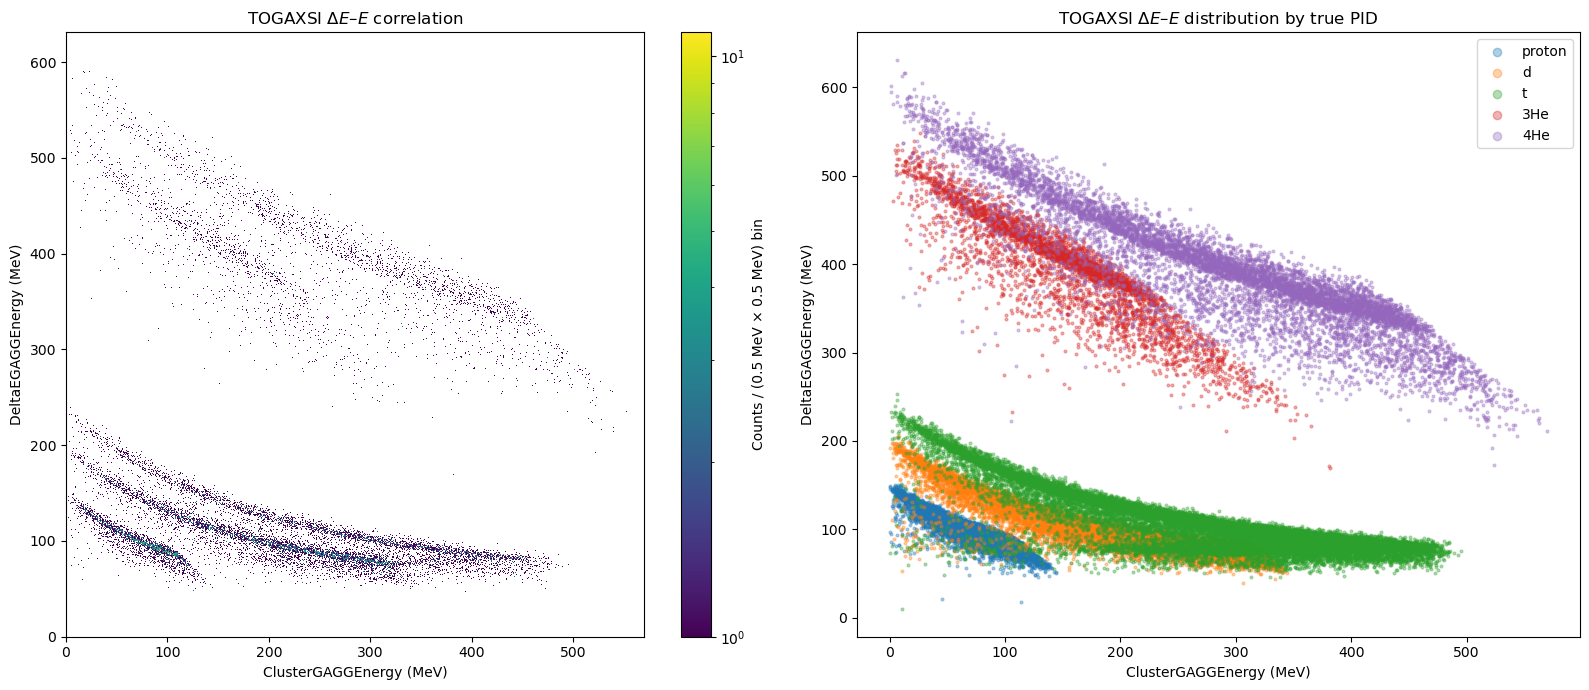

In [27]:
# 功能：绘制 TOGAXSI 原始 ΔE–E 二维能量关联图，以及按照真实 PID 着色的 ΔE–E 分布。
# 方法：左图使用 0.5 MeV 等宽 bin 和对数色标；右图按照 ROOT 中真实 PID 分类绘制散点。
# 注意事项：读取第 2 节的原始 X 和真实标签 y；同一事件多条径迹分别计数，不对能量归一化。

from matplotlib.colors import LogNorm

ENERGY_BIN_WIDTH_MEV = 0.5

cluster_energy = X[:, FEATURE_NAMES.index('ClusterGAGGEnergy')]
delta_energy = X[:, FEATURE_NAMES.index('DeltaEGAGGEnergy')]

def energy_edges(energy):
    n_bins = max(1, int(np.ceil(energy.max() / ENERGY_BIN_WIDTH_MEV)))
    return np.arange(n_bins + 1, dtype=np.float64) * ENERGY_BIN_WIDTH_MEV

x_edges = energy_edges(cluster_energy)
y_edges = energy_edges(delta_energy)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 左图：原始 ΔE-E 二维计数分布
hist, _, _, image = axes[0].hist2d(
    cluster_energy,
    delta_energy,
    bins=[x_edges, y_edges],
    norm=LogNorm(),
    cmap='viridis',
    cmin=1,
)

axes[0].set_xlabel('ClusterGAGGEnergy (MeV)')
axes[0].set_ylabel('DeltaEGAGGEnergy (MeV)')
axes[0].set_title(r'TOGAXSI $\Delta E$–$E$ correlation')

fig.colorbar(image,ax=axes[0],label='Counts / (0.5 MeV × 0.5 MeV) bin',)

# 右图：按照 ROOT 中真实 PID 着色
for pid, name in enumerate(CLASS_NAMES):
    mask = (y == pid)
    axes[1].scatter(
        cluster_energy[mask],
        delta_energy[mask],
        s=4,
        alpha=0.35,
        label=name,
    )

axes[1].set_xlabel('ClusterGAGGEnergy (MeV)')
axes[1].set_ylabel('DeltaEGAGGEnergy (MeV)')
axes[1].set_title(r'TOGAXSI $\Delta E$–$E$ distribution by true PID')
axes[1].legend(markerscale=3)

fig.tight_layout()
plt.show()

## 3. 训练集标准化与 CPU 数据

标准化特征使用 CPU float64，分类标签使用 CPU int64；每轮打乱后按切片分批。


In [28]:
# 功能：仅用训练集计算两项能量的均值/标准差，并构建 CPU 训练与测试张量。
# 方法：复用训练标准化参数转换全部数据，每轮按 randperm 打乱并切片分批。
# 注意事项：标准差为零时替换为 1；特征保持 float64、标签保持 int64；数据需能放入内存。
x_mean = X[train_idx].mean(axis=0)
x_std = X[train_idx].std(axis=0)
x_std = np.where(x_std == 0.0, 1.0, x_std)
X_scaled = (X - x_mean) / x_std
if not np.all(np.isfinite(X_scaled)):
    raise ValueError('标准化后出现 NaN/Inf')
X_train_t = torch.from_numpy(np.ascontiguousarray(X_scaled[train_idx])).to(device=device, dtype=DTYPE)
y_train_t = torch.from_numpy(np.ascontiguousarray(y[train_idx])).to(device=device, dtype=torch.long)
X_test_t = torch.from_numpy(np.ascontiguousarray(X_scaled[test_idx])).to(device=device, dtype=DTYPE)
y_test_t = torch.from_numpy(np.ascontiguousarray(y[test_idx])).to(device=device, dtype=torch.long)

def iter_batches(X_t, y_t, batch_size, shuffle=False):
    if shuffle:
        order = torch.randperm(len(X_t), device=device)
        X_t, y_t = X_t[order], y_t[order]
    for start in range(0, len(X_t), batch_size):
        yield X_t[start:start + batch_size], y_t[start:start + batch_size]


## 3.1 单独定义神经网络

显式定义 2 → 64 → 64 → 64 → 5，三个隐藏层使用 ReLU。输入为两项标准化 GAGG 能量，输出为五类原始 logits；最后一层不加 Softmax。


In [29]:
# 功能：独立定义五分类 MLP，便于直接修改网络层数和宽度。
# 方法：三个 64 节点 ReLU 隐藏层，输入为两项标准化 GAGG 能量，线性输出层返回五维 logits。
# 注意事项：模型在初始化单元格固定使用 CPU，使用配置单元格设置的 DTYPE；训练损失直接使用 logits。

# 当前结构为三个 64 节点 ReLU 隐藏层，输出五维原始 logits。
def build_model():
    return nn.Sequential(
        nn.Linear(2, 64), nn.ReLU(),
        nn.Linear(64, 64), nn.ReLU(),
        nn.Linear(64, 64), nn.ReLU(),
        nn.Linear(64, 5),
    )

# 以下为未启用的较宽网络示例，实际训练调用上面的 build_model。
# def build_model():
#     return nn.Sequential(
#         nn.Linear(2, 128), nn.ReLU(),
#         nn.Linear(128, 128), nn.ReLU(),
#         nn.Linear(128, 128), nn.ReLU(),
#         nn.Linear(128, 5),
#     )

# fork_rng 避免仅打印网络就改变后续模型初始化的随机状态。
with torch.random.fork_rng(devices=[]):
    print(build_model())


Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=5, bias=True)
)


## 3.2 初始化模型、损失与优化器

每次重新训练前执行本单元格，创建新的模型和优化器。保存检查点时从实际模型读取隐藏层宽度。


In [30]:
# 功能：在 CPU 初始化新的训练模型、交叉熵损失及 Adam 优化器。
# 方法：调用 build_model，固定初始化种子并显式使用配置的设备与精度。
# 注意事项：先执行两输入网络定义；每次训练前重新初始化，本单元格不加载检查点。
torch.manual_seed(SEED)
model = build_model().to(device=device, dtype=DTYPE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


## 4. 固定轮数训练

每轮参数更新完毕后，在同一模型状态下重算完整训练和测试集合的损失。测试仅监控，保留最后一轮权重。

In [31]:
# 功能：在 CPU 上训练和评估，每轮汇总完整集指标。
# 方法：常驻张量切片分批；CPU 累加损失和准确率，保持每轮最终权重评价。
# 注意事项：非有限训练损失在轮末检查，异常后须重新初始化；测试只用于监控。
def evaluate_tensors(network, X_t, y_t):
    network.eval()
    loss_sum = torch.zeros((), device=device, dtype=DTYPE)
    correct = torch.zeros((), device=device, dtype=torch.long)
    with torch.no_grad():
        for xb, yb in iter_batches(X_t, y_t, EVAL_BATCH_SIZE):
            logits = network(xb)
            loss_sum += criterion(logits, yb) * len(yb)
            correct += (logits.argmax(dim=1) == yb).sum()
    return loss_sum / len(y_t), correct.to(dtype=DTYPE) / len(y_t)

import time
train_loss_history, test_loss_history = [], []
train_accuracy_history, test_accuracy_history = [], []
training_start = time.perf_counter()
for epoch in range(1, EPOCH_COUNT + 1):
    model.train()
    finite_losses = torch.ones((), device=device, dtype=torch.bool)
    for xb, yb in iter_batches(X_train_t, y_train_t, BATCH_SIZE, shuffle=True):
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        finite_losses.logical_and_(torch.isfinite(loss.detach()))
        loss.backward()
        optimizer.step()
    train_loss_t, train_accuracy_t = evaluate_tensors(model, X_train_t, y_train_t)
    test_loss_t, test_accuracy_t = evaluate_tensors(model, X_test_t, y_test_t)
    metrics = torch.stack((train_loss_t, test_loss_t, train_accuracy_t,
                           test_accuracy_t, finite_losses.to(dtype=DTYPE))).detach().cpu().numpy()
    if not np.all(np.isfinite(metrics)) or metrics[4] != 1.0:
        raise FloatingPointError(f'epoch {epoch}: 非有限损失；须重新初始化模型')
    train_loss, test_loss, train_accuracy, test_accuracy = map(float, metrics[:4])
    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)
    train_accuracy_history.append(train_accuracy)
    test_accuracy_history.append(test_accuracy)
    if epoch == 1 or epoch % 100 == 0 or epoch == EPOCH_COUNT:
        average_seconds = (time.perf_counter() - training_start) / epoch
        print(f'epoch {epoch:4d}: train CE={train_loss:.6f}, test CE={test_loss:.6f}, '
              f'train acc={train_accuracy:.4f}, test acc={test_accuracy:.4f}, '
              f'average={average_seconds:.3f} s/epoch')
model.eval()


epoch    1: train CE=0.462440, test CE=0.459069, train acc=0.8358, test acc=0.8319, average=0.127 s/epoch
epoch  100: train CE=0.183944, test CE=0.183466, train acc=0.9292, test acc=0.9286, average=0.170 s/epoch
epoch  200: train CE=0.181759, test CE=0.181803, train acc=0.9295, test acc=0.9274, average=0.168 s/epoch
epoch  300: train CE=0.179430, test CE=0.179544, train acc=0.9301, test acc=0.9279, average=0.178 s/epoch
epoch  400: train CE=0.180227, test CE=0.179916, train acc=0.9293, test acc=0.9264, average=0.178 s/epoch
epoch  500: train CE=0.177569, test CE=0.178434, train acc=0.9307, test acc=0.9275, average=0.179 s/epoch


Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=5, bias=True)
)

## 5. 损失与准确率曲线

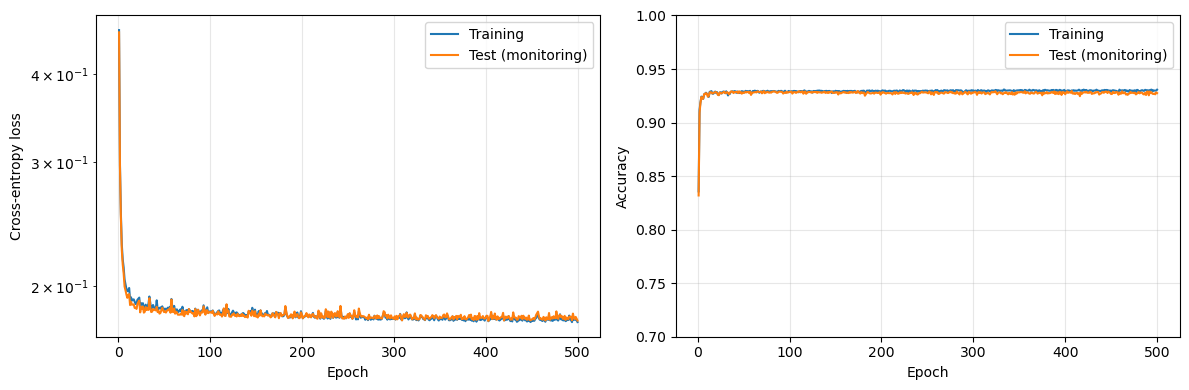

In [32]:
# 功能：显示固定轮数训练期间的交叉熵与分类准确率曲线。
# 方法：绘制每轮最终权重下完整训练集、测试监控集的重算指标。
# 注意事项：测试曲线用于开发监控，不用于早停或权重选择；需先完成训练。
epochs = np.arange(1, EPOCH_COUNT + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_loss_history, label='Training')
axes[0].plot(epochs, test_loss_history, label='Test (monitoring)')
axes[0].set(xlabel='Epoch', ylabel='Cross-entropy loss', yscale='log')
axes[1].plot(epochs, train_accuracy_history, label='Training')
axes[1].plot(epochs, test_accuracy_history, label='Test (monitoring)')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', ylim=(0.7, 1))
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 6. 测试分类评价与两种输出

`logits[i, j]` 是第 i 个样本对第 j 类的原始分数，可为负、无固定范围，也不要求和为 1。`probabilities[i, j] = exp(logit_j) / sum_k exp(logit_k)` 位于 [0,1]，每行和为 1。两者 argmax 相同，均按 proton、d、t、3He、4He 排列。

Softmax 是模型给出的类别概率，未经校准，不能把最大概率直接当作经过验证的鉴别可靠度。混淆矩阵行是真实类别，列是预测类别；这些指标仅使用测试事件。

Test accuracy: 0.9275323032438781
Macro F1: 0.9371423586343394 Balanced accuracy: 0.9466383056556513
0 proton: support=1664, precision=0.9656, recall=0.9964, F1=0.9808
1 d: support=3174, precision=0.8515, recall=0.9609, F1=0.9029
2 t: support=3812, precision=0.9714, recall=0.8539, F1=0.9088
3 3He: support=764, precision=0.8795, recall=0.9843, F1=0.9290
4 4He: support=1653, precision=0.9923, recall=0.9377, F1=0.9642
Entry=0, EventID=1, true=t, pred=d
  raw logits: {'proton': -24.489311033463366, 'd': 2.365362098674605, 't': 2.1817513763060177, '3He': -7.121475126212566, '4He': -6.478566278174476}
  Softmax probabilities: {'proton': 1.1861085727070197e-12, 'd': 0.5457086017562988, 't': 0.4541712885732976, '3He': 4.138850523523637e-05, '4He': 7.872116398222928e-05}
Entry=10, EventID=124, true=proton, pred=proton
  raw logits: {'proton': 4.1214118658759284, 'd': -1.5406432406490536, 't': -1.8088594480975166, '3He': -22.87762665942388, '4He': -19.129927526822346}
  Softmax probabilities: {'

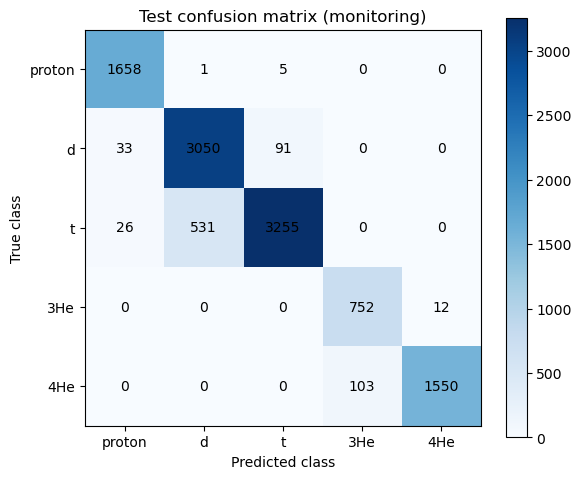

In [33]:
# 功能：输出测试监控集的分类指标、logits、Softmax 概率及混淆矩阵。
# 方法：eval/no_grad 分批预测，argmax 分类；混淆矩阵行是真值、列是预测。
# 注意事项：概率未经校准；标签索引顺序为 proton、d、t、3He、4He；样本按 test_idx 对齐。
test_logits, test_probabilities = predict_scores(model, X_test_t)
test_pred = test_logits.argmax(axis=1)
y_test = y[test_idx]
confusion = np.zeros((5, 5), dtype=np.int64)
np.add.at(confusion, (y_test, test_pred), 1)
true_count = confusion.sum(axis=1)
pred_count = confusion.sum(axis=0)
precision = np.divide(np.diag(confusion), pred_count, out=np.zeros(5), where=pred_count > 0)
recall = np.divide(np.diag(confusion), true_count, out=np.zeros(5), where=true_count > 0)
f1 = np.divide(2 * precision * recall, precision + recall,
               out=np.zeros(5), where=(precision + recall) > 0)
print('Test accuracy:', float(np.mean(test_pred == y_test)))
print('Macro F1:', float(f1.mean()), 'Balanced accuracy:', float(recall.mean()))
for j, name in enumerate(CLASS_NAMES):
    print(f'{j} {name}: support={true_count[j]}, precision={precision[j]:.4f}, '
          f'recall={recall[j]:.4f}, F1={f1[j]:.4f}')
for i in range(min(5, len(test_idx))):
    row = test_idx[i]
    print(f"Entry={row}, EventID={event_ids[row]}, true={CLASS_NAMES[y_test[i]]}, "
          f"pred={CLASS_NAMES[test_pred[i]]}")
    print('  raw logits:', dict(zip(CLASS_NAMES, test_logits[i].tolist())))
    print('  Softmax probabilities:', dict(zip(CLASS_NAMES, test_probabilities[i].tolist())))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(confusion, cmap='Blues')
for i in range(5):
    for j in range(5):
        ax.text(j, i, str(confusion[i, j]), ha='center', va='center')
ax.set(xticks=np.arange(5), yticks=np.arange(5), xticklabels=CLASS_NAMES,
       yticklabels=CLASS_NAMES, xlabel='Predicted class', ylabel='True class',
       title='Test confusion matrix (monitoring)')
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()


## 7. 保存最后一轮完整模型和预处理

仅加载自己生成且可信的完整模型文件。检查点记录输入顺序、单位、标签映射、事件划分与训练历史。

In [34]:
# 功能：保存最后一轮的完整 CPU 模型及训练标准化、特征、类别和事件划分信息。
# 方法：深拷贝当前模型，连同配置及训练历史保存为单个 PID_model.pt。
# 注意事项：执行会覆盖对应输出目录的同名模型；完整模型仅从可信文件加载；不导出 CSV。
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# 保存 CPU 上的独立完整 nn.Sequential 对象和实际网络结构。
import copy
saved_model = copy.deepcopy(model).cpu().eval()
torch.save({
    'model': saved_model,
    'feature_names': FEATURE_NAMES.copy(), 'feature_units': ['MeV'] * len(FEATURE_NAMES),
    'class_names': CLASS_NAMES.copy(), 'class_to_pid': {n: i for i, n in enumerate(CLASS_NAMES)},
    'x_mean': x_mean, 'x_std': x_std, 'dtype': str(DTYPE).removeprefix('torch.'),
    'tree_name': TREE_NAME, 'input_path': str(ROOT_PATH), 'seed': SEED,
    'train_event_ids': train_events, 'test_event_ids': test_events,
    'train_entries': train_idx, 'test_entries': test_idx,
    'epoch_count': EPOCH_COUNT, 'checkpoint_policy': 'final_epoch',
    'hidden_sizes': [layer.out_features for layer in model if isinstance(layer, nn.Linear)][:-1],
    'hidden_activation': 'ReLU', 'device': str(device), 'learning_rate': LEARNING_RATE, 'batch_size': BATCH_SIZE,
    'train_loss_history': train_loss_history, 'test_loss_history': test_loss_history,
    'train_accuracy_history': train_accuracy_history, 'test_accuracy_history': test_accuracy_history,
}, MODEL_PATH)
print('Saved complete model:', MODEL_PATH)

Saved complete model: /Users/yemingxin/ROOT_Exercise/MachineLearning/PID/PID_SSD_outputs/PID_model.pt


## 8. 模型分类区域、测试散点与误分类标记

最后一个单元格只显示一张图：半透明背景（alpha=0.25）表示模型预测类别，黑色实线表示分类边界，散点按测试事件的预测 PID 着色，黑色 `×` 标记预测 PID 与 ROOT 真实 PID 不一致的测试事件。第 2.1 节的散点图按真实 PID 着色，两处含义不同。

边界生成流程：在原始能量平面建立 500 × 500 网格，x 为 ClusterGAGGEnergy，y 为 DeltaEGAGGEnergy；按 FEATURE_NAMES 顺序填入两项能量，使用训练集 x_mean/x_std 标准化，在 eval/no_grad 模式下直接调用当前两输入模型，取五维 logits 的 argmax 作为类别。对每类建立属于该类为 1、否则为 0 的二值区域，再用 contour 的 levels=[0.5] 提取区域分界。这里的 0.5 是二值区域轮廓阈值，不是 Softmax 概率阈值，也不对 PID 编号做连续插值。

分类区域来自二维模型直接预测，不使用 SSD 能量、固定 SSD 切片或近邻插值。黑线是有限网格上的数值轮廓，窄小区域可能受网格分辨率影响；数据稀疏处为模型外推。理论上的两类交界处，其 logits 相等且共同不低于其他类别。背景与散点都使用当前内存模型和训练标准化参数；重新训练或修改配置后需按顺序执行相关单元格，最后一个单元格不会自动加载模型文件或训练模型。


/var/folders/hr/dw8m1b256kd8zg2qbd9c0fsm0000gn/T/ipykernel_49546/2163624207.py:69: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


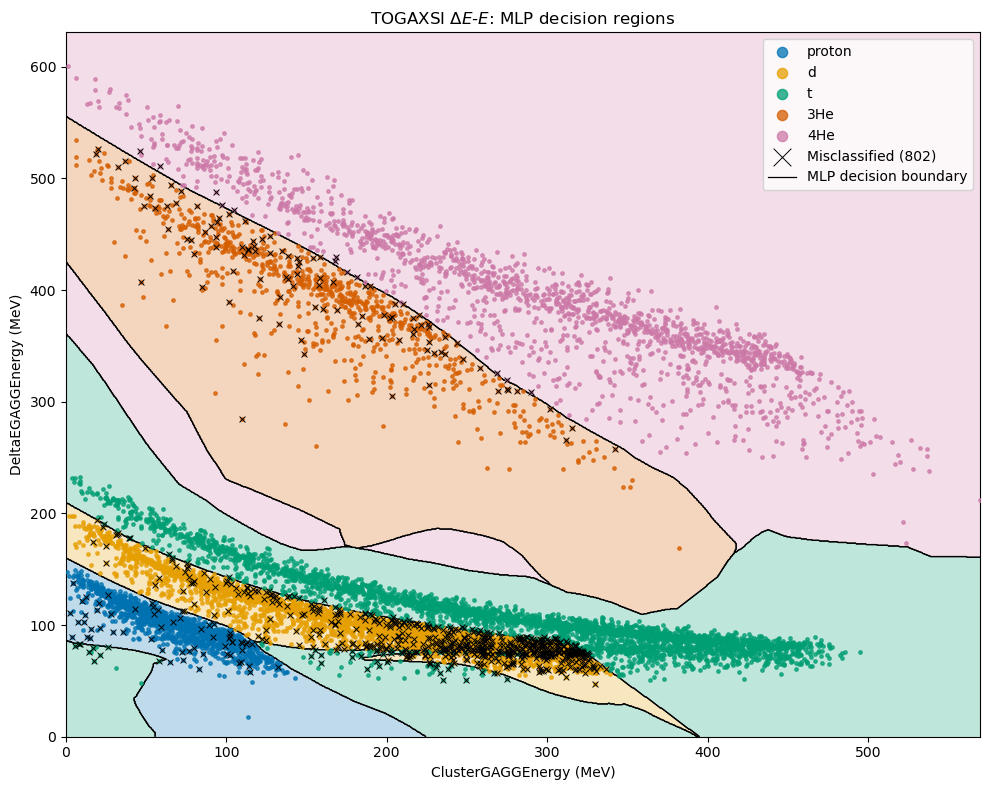

In [35]:
# 功能：直接绘制两输入 MLP 的半透明 ΔE-E 分类区域、黑色边界、测试散点及误分类 ×。
# 方法：原始二维网格复用训练均值/标准差后直接输入模型，按 logits argmax 着色；
#       各类别二值区域的 0.5 等高线提取边界，预测与真实 PID 不同的测试事件叠加黑色 ×。
# 注意事项：需先完成两输入模型训练；边界是 GRID_SIZE 网格上的数值轮廓，稀疏处为模型外推；
#           散点按预测 PID 着色，特征和模型保持 CPU float64；不使用 SSD 能量或近邻插值。
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

cluster_column = FEATURE_NAMES.index('ClusterGAGGEnergy')
delta_column = FEATURE_NAMES.index('DeltaEGAGGEnergy')
if (len(FEATURE_NAMES) != 2 or X.shape[1] != 2
        or np.asarray(x_mean).shape != (2,) or np.asarray(x_std).shape != (2,)
        or next(layer for layer in model.modules() if isinstance(layer, nn.Linear)).in_features != 2):
    raise ValueError('当前数据或模型仍非两输入，请从配置单元格起重新执行并训练两输入模型')
plot_energy = X[test_idx]
cluster_energy = plot_energy[:, cluster_column]
delta_energy = plot_energy[:, delta_column]

# 测试散点及误分类标记使用各事件的两项 GAGG 能量。
event_scaled = np.ascontiguousarray((plot_energy - x_mean) / x_std)
event_t = torch.from_numpy(event_scaled).to(device=device, dtype=DTYPE)
event_logits, _ = predict_scores(model, event_t)
event_pred = event_logits.argmax(axis=1)
misclassified = event_pred != y[test_idx]

# 在原始ΔE-E平面建立500*500的网格，即选取了25w个数据点，按特征顺序及训练标准化直接送入二维模型。
#GRID_SIZE = 500
GRID_SIZE = 1000
cluster_grid = np.linspace(0.0, X[:, cluster_column].max(), GRID_SIZE)
delta_grid = np.linspace(0.0, X[:, delta_column].max(), GRID_SIZE)
xx, yy = np.meshgrid(cluster_grid, delta_grid)
grid_raw = np.empty((xx.size, len(FEATURE_NAMES)), dtype=np.float64)
grid_raw[:, cluster_column] = xx.ravel()
grid_raw[:, delta_column] = yy.ravel()
grid_scaled = np.ascontiguousarray((grid_raw - x_mean) / x_std)
grid_t = torch.from_numpy(grid_scaled).to(device=device, dtype=DTYPE)
grid_logits, _ = predict_scores(model, grid_t)
grid_pred = grid_logits.argmax(axis=1).reshape(xx.shape)

class_colors = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7']
cmap = ListedColormap(class_colors)
norm = BoundaryNorm(np.arange(-0.5, len(CLASS_NAMES) + 0.5, 1.0), cmap.N)
fig, ax = plt.subplots(figsize=(10, 8))
ax.pcolormesh(xx, yy, grid_pred, cmap=cmap, norm=norm, shading='auto', alpha=0.25)
#代码并没有直接对 grid_pred=0,1,2,3,4 做连续等高线，而是对每一种粒子单独建立一个 0/1 区域
# 对每类 0/1 区域提取 0.5 轮廓；0.5 不是概率阈值，不对 PID 编号作连续插值。
for pid in range(len(CLASS_NAMES)):
    region = (grid_pred == pid).astype(np.float64)
    if region.min() != region.max():
        ax.contour(xx, yy, region, levels=[0.5], colors='black', linewidths=0.9, zorder=3)
for pid, name in enumerate(CLASS_NAMES):
    mask = event_pred == pid
    ax.scatter(cluster_energy[mask], delta_energy[mask], s=6,
               color=class_colors[pid], alpha=0.75, label=name, zorder=4)
ax.scatter(
    cluster_energy[misclassified], delta_energy[misclassified],
    s=18, marker='x', color='black', linewidths=0.7, zorder=5,
    label=f'Misclassified ({int(misclassified.sum())})',
)
ax.set_xlabel('ClusterGAGGEnergy (MeV)')
ax.set_ylabel('DeltaEGAGGEnergy (MeV)')
ax.set_xlim(cluster_grid[0], cluster_grid[-1])
ax.set_ylim(delta_grid[0], delta_grid[-1])
ax.set_title(r'TOGAXSI $\Delta E$-$E$: MLP decision regions')
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([0], [0], color='black', linewidth=0.9))
labels.append('MLP decision boundary')
ax.legend(handles, labels, markerscale=3)
fig.tight_layout()
plt.show()
